# Análise Exploratória e Tratamento de Dados

Teste de Hip para MCAR : rejeitamos. dados ausentes dependem de alguma forma das outras colunas.

Teste de Kolmogorov Smirnof para ver se gamma ou log-normal se ajustavam melhor a distrib de Y.

Validação

Imputação: link (g) = identidade, dist. log(y) normal.

Hips:

1- Y é explicada por X

2-  conjunto paramétrico de distribuição família exponencial para Y

3- g conecta a esperança de Y a soma das f_i - a média da resposta de y transformada por g é aditiva nos efeitos das varivaveis x_i's.

4-Não há iteração entre as variáveis - efeitos independentes.

5- Observações independentes.

E, como estamos usandos splines, estamos assumindo que as f_i's são suaves.

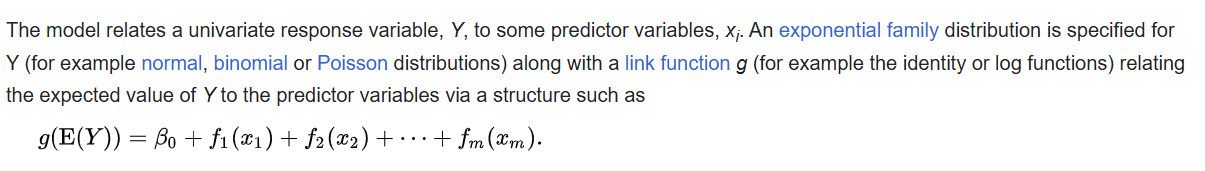

https://rianneschouten.github.io/pyampute/build/html/pyampute.exploration.html

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyampute.exploration.mcar_statistical_tests import MCARTest

In [6]:
#dictionary = pd.read_csv(r"~\ML1\Data Dictionary.csv", index_col=0) # dicionario das features
df_tr = pd.read_csv("cs-training.csv", index_col=0) # dataframe de treino sem o índice
df_te  = pd.read_csv("cs-test.csv",  index_col=0) # dataframe de teste sem o índice
df_s = pd.read_csv("sampleEntry.csv", index_col=0) # dataframe de amostra de submissão

print("TRAIN shape:", df_tr.shape)
print("TEST  shape:", df_te.shape)
print("SAMPLE shape:", df_s.shape)

TRAIN shape: (150000, 11)
TEST  shape: (101503, 11)
SAMPLE shape: (101503, 1)


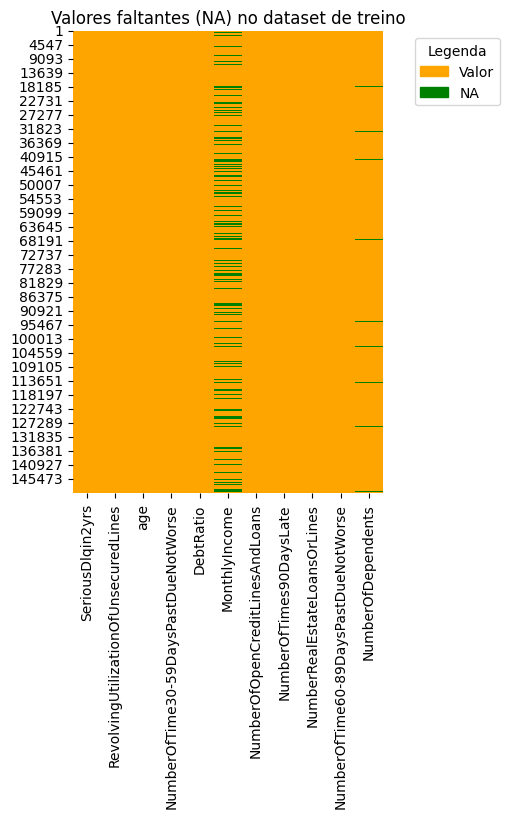

In [7]:
composite_train = df_tr.isna().astype(int)

colors = ['orange', 'green']  # 0 = Valor, 1 = NaN
custom_cmap = sns.color_palette(colors)

plt.figure(figsize=(4, 6))
sns.heatmap(composite_train, cbar=False, cmap=custom_cmap, vmax=1, vmin=0)
handles = [plt.Rectangle((0,0),1,1, color=custom_cmap[i]) for i in range(len(colors))]
plt.legend(handles, ["Valor", "NA"], title="Legenda", loc="upper right", bbox_to_anchor=(1.4, 1))
plt.title("Valores faltantes (NA) no dataset de treino")
plt.show()

In [8]:
df_te = df_te.drop(columns=['SeriousDlqin2yrs'])


df_te['SeriousDlqin2yrs'] = df_s['Probability']

print(f"Novo shape do df_te:", df_te.shape)
df_te.head()

Novo shape do df_te: (101503, 11)


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
1,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0,0.080807
2,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0,0.040719
3,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0,0.011968
4,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0,0.067640
5,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0,0.108264


In [9]:
df_c = pd.concat(
    [df_tr, df_te],
    axis=0,
    ignore_index=True
)

print(df_c.shape)


(251503, 11)


In [10]:
df_c.dropna(subset=['NumberOfDependents'], inplace=True)

In [11]:
mcar_tester = MCARTest(method='little')

pv = mcar_tester.little_mcar_test(df_c)

pv

np.float64(0.0)

In [12]:
renda_sem_nan = df_c['MonthlyIncome'].dropna()

quartis = renda_sem_nan.quantile([0.25, 0.5, 0.75, 0.9, 0.99, 0.9999])
print(quartis)

print(renda_sem_nan.skew())
print(renda_sem_nan.max())
print(renda_sem_nan.min())

0.2500      3400.00
0.5000      5400.00
0.7500      8212.00
0.9000     11600.00
0.9900     25050.36
0.9999    438040.10
Name: MonthlyIncome, dtype: float64
195.75627387813307
7727000.0
0.0


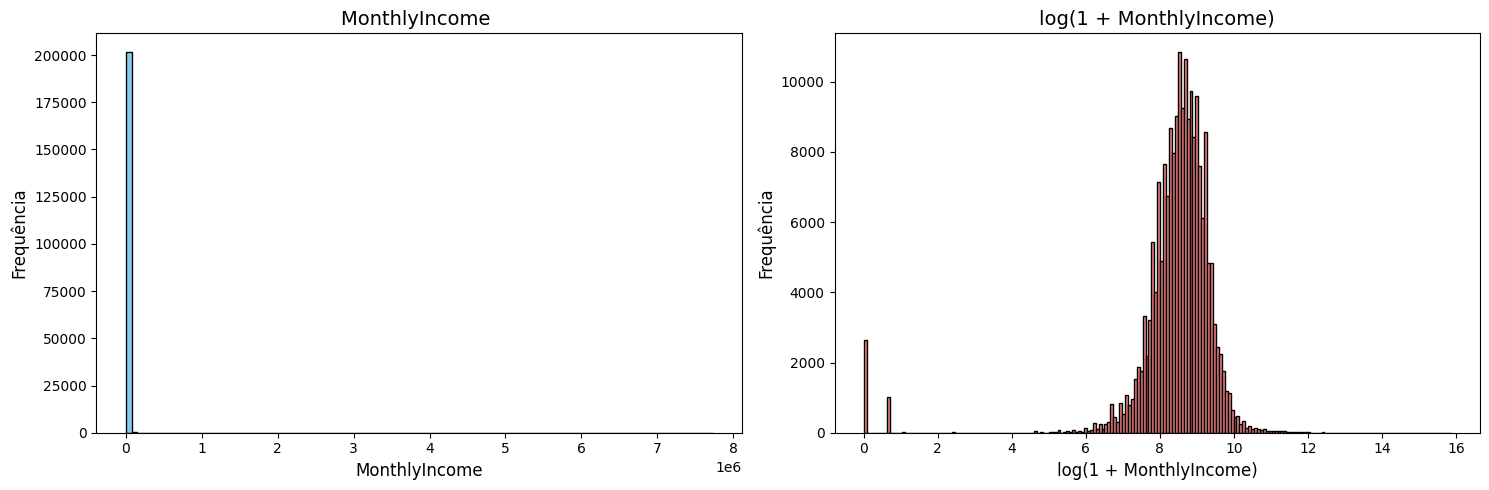

In [13]:
renda_original = df_c['MonthlyIncome'].dropna()

renda_log = np.log1p(renda_original)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(renda_original, bins=100, color='skyblue', edgecolor='black')
axes[0].set_title('MonthlyIncome ', fontsize=14)
axes[0].set_xlabel('MonthlyIncome', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)

axes[1].hist(renda_log, bins=200, color='lightcoral', edgecolor='black')
axes[1].set_title('log(1 + MonthlyIncome)', fontsize=14)
axes[1].set_xlabel('log(1 + MonthlyIncome)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()

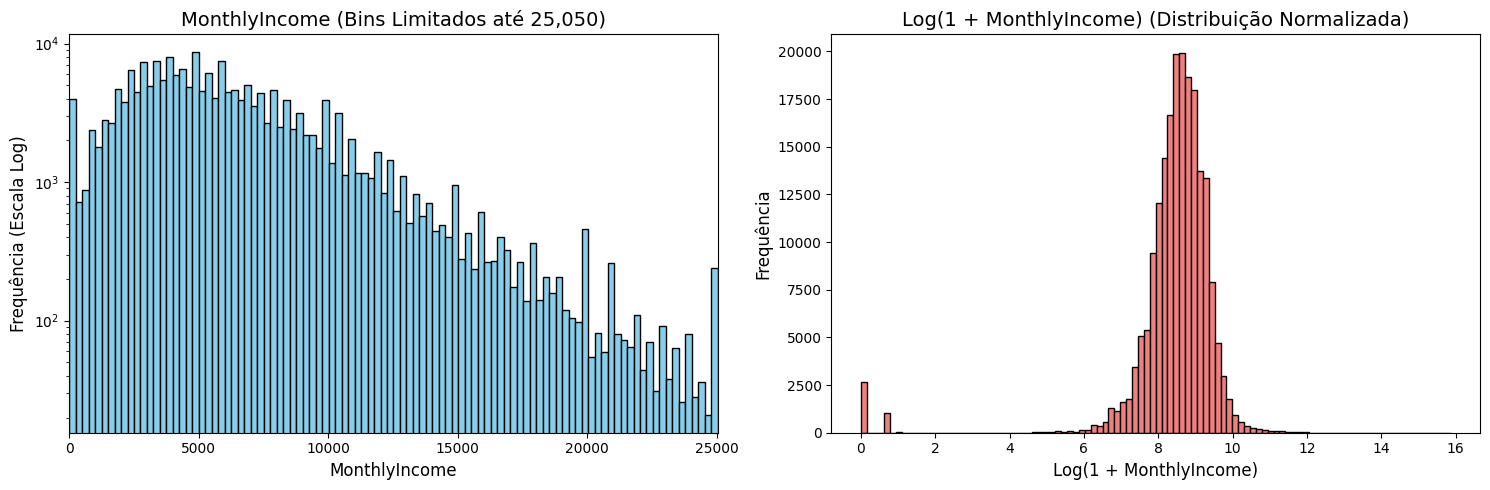

O limite de corte usado para criar os bins foi o 99º percentil: R$ 25,050.36


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare os dados (remover NaN)
renda_original = df_c['MonthlyIncome'].dropna()
renda_log = np.log1p(renda_original)

# 2. Definir o novo limite para o cálculo dos BINS
# Vamos usar o 99º percentil para incluir 99% dos dados
limite_para_bins = renda_original.quantile(0.99)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Histograma da Renda Original (CORRIGIDO) ---

# AQUI ESTÁ A MUDANÇA ESSENCIAL:
# Usamos 'range=(0, limite_para_bins)' para que os 100 bins sejam criados
# de forma uniforme APENAS dentro desta faixa de 0 a limite_para_bins.
axes[0].hist(
    renda_original,
    bins=100,
    range=(0, limite_para_bins),
    color='skyblue',
    edgecolor='black'
)

axes[0].set_title(f'MonthlyIncome (Bins Limitados até {limite_para_bins:,.0f})', fontsize=14)
axes[0].set_xlabel('MonthlyIncome', fontsize=12)
axes[0].set_ylabel('Frequência (Escala Log)', fontsize=12)

# Manter a escala logarítmica no Eixo Y ajuda a ver a diferença entre as barras
axes[0].set_yscale('log')

# O set_xlim agora é redundante, mas confirma o limite visual
axes[0].set_xlim(0, limite_para_bins)


# --- Histograma da Renda Transformada (Log) ---
axes[1].hist(renda_log, bins=100, color='lightcoral', edgecolor='black')
axes[1].set_title('Log(1 + MonthlyIncome) (Distribuição Normalizada)', fontsize=14)
axes[1].set_xlabel('Log(1 + MonthlyIncome)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()

print(f"O limite de corte usado para criar os bins foi o 99º percentil: R$ {limite_para_bins:,.2f}")

In [15]:
from scipy.stats import lognorm, gamma, kstest

renda_original = renda_original + 1

params_lognorm = lognorm.fit(renda_original)
s_ln, loc_ln, scale_ln = params_lognorm


params_gamma = gamma.fit(renda_original)
a_g, loc_g, scale_g = params_gamma


ks_stat_ln, p_value_ln = kstest(renda_original, 'lognorm', args=params_lognorm)

ks_stat_g, p_value_g = kstest(renda_original, 'gamma', args=params_gamma)

print("\n LOG-NORMAL")
print(f"KS Statistic (D): {ks_stat_ln:.4f}")
print(f"P-valor", p_value_ln)


print("\n GAMMA")
print(f"KS Statistic (D): {ks_stat_g:.4f}")
print(f"P-valor", p_value_g)




 LOG-NORMAL
KS Statistic (D): 0.0283
P-valor 1.3272385460014042e-140

 GAMMA
KS Statistic (D): 1.0000
P-valor 0.0


In [16]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244953 entries, 0 to 251502
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      244953 non-null  float64
 1   RevolvingUtilizationOfUnsecuredLines  244953 non-null  float64
 2   age                                   244953 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  244953 non-null  int64  
 4   DebtRatio                             244953 non-null  float64
 5   MonthlyIncome                         201669 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       244953 non-null  int64  
 7   NumberOfTimes90DaysLate               244953 non-null  int64  
 8   NumberRealEstateLoansOrLines          244953 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  244953 non-null  int64  
 10  NumberOfDependents                    244953 non-null  float64
dtypes: fl

In [17]:
df_c.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,244953.000000,244953.000000,244953.000000,244953.000000,244953.000000,2.016690e+05,244953.000000,244953.000000,244953.000000,244953.000000,244953.000000
mean,0.067677,5.689943,52.145877,0.420628,331.537394,6.744818e+03,8.529036,0.262512,1.028242,0.236674,0.761995
std,0.205988,230.310730,14.605595,4.146371,1825.891030,2.571761e+04,5.146429,4.121278,1.125249,4.107044,1.123905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.031093,41.000000,0.000000,0.171311,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.158062,52.000000,0.000000,0.356968,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.022149,0.565351,62.000000,0.000000,0.761885,8.212000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,107.000000,98.000000,329664.000000,7.727000e+06,85.000000,98.000000,54.000000,98.000000,43.000000


In [21]:
from pygam import LinearGAM, s
from sklearn.model_selection import GridSearchCV, KFold
import numpy as np
import matplotlib.pyplot as plt

df = df_c.copy()

mask_complete = df['MonthlyIncome'].notnull()
mask_missing = df['MonthlyIncome'].isnull()

cols_to_use = [c for c in df.columns if c not in ['MonthlyIncome', 'SeriousDlqin2yrs']]

X = df.loc[mask_complete, cols_to_use]
y = np.log(df.loc[mask_complete, 'MonthlyIncome'])

terms = s(0)
for i in range(1, X.shape[1]):
    terms += s(i)


/Users/marcosabilio/.venv2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [31]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

gam = LinearGAM()

param_grid = {
    'lam': [0.1, 1, 10, 100],
    'n_splines': [10, 20, 30]
}

grid = GridSearchCV(
    estimator=gam,
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid.fit(X.values, y.values)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor R² médio (validação cruzada):", grid.best_score_)


RuntimeError: Cannot clone object LinearGAM(callbacks=['deviance', 'diffs'], fit_intercept=True, 
   max_iter=100, scale=None, terms='auto', tol=0.0001, verbose=False), as the constructor either does not set or modifies parameter callbacks

In [ ]:
best_gam = grid.best_estimator_
best_gam.fit(X.values, y.values)

In [ ]:

X_missing = df.loc[mask_missing, cols_to_use]

y_pred = best_gam.predict(X_missing.values)

y_pred = np.maximum(y_pred, 0)

In [ ]:
# Criar um dataframe imputado
df_imputed = df.copy()
df_imputed.loc[mask_missing, 'MonthlyIncome'] = y_pred


In [ ]:
print(f"Número de imputações: {mask_missing.sum()}")
print(f"Valores imputados → min={y_pred.min():.2f}, max={y_pred.max():.2f}, média={y_pred.mean():.2f}")

assert (df_imputed['MonthlyIncome'] >= 0).all(), "Há valores negativos imputados!"

plt.figure(figsize=(8,5))
plt.hist(df.loc[mask_complete, 'MonthlyIncome'], bins=50, alpha=0.5, label='Originais')
plt.hist(df_imputed.loc[mask_missing, 'MonthlyIncome'], bins=50, alpha=0.5, label='Imputados')
plt.legend()
plt.title("Distribuição de MonthlyIncome: Originais vs Imputados")
plt.show()


In [ ]:
df_tn = df_imputed[
    (df_imputed['SeriousDlqin2yrs'] == 0) | (df_imputed['SeriousDlqin2yrs'] == 1)
].copy()


df_tt = df_imputed[
    (df_imputed['SeriousDlqin2yrs'] != 0) & (df_imputed['SeriousDlqin2yrs'] != 1)
].copy()


df_tn.to_csv('df_tn.csv', index=False)

df_tt.to_csv('df_tt.csv', index=False)